# Wind Forecast Analysis - January 2024
### Technical Assessment Submission

**Objective:** To understand forecast error characteristics and determine the reliable wind capacity available to the grid based on first principles.

**Key Constraints:**
- Filters forecasts to the **4–48 hour horizon** to match operational balancing logic.
- Analyzes error variance by time of day and forecast lead time.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Step 1: Load Data
df_actuals = pd.read_csv('wind_actuals_jan2024.csv')
df_forecasts = pd.read_csv('wind_forecasts_jan2024.csv')

# Step 2: Clean and Convert Timestamps (Using specific column names from CSVs)
df_actuals['startTime'] = pd.to_datetime(df_actuals['startTime'])
df_forecasts['startTime'] = pd.to_datetime(df_forecasts['startTime'])
df_forecasts['publishTime'] = pd.to_datetime(df_forecasts['publishTime'])

## 1. Operational Filtering & Processing
**Reasoning:** We focus on the 4–48 hour window as it represents the actionable timeframe for day-ahead and intraday grid management. Forecasts outside this window are either too volatile (long-term) or too late for major adjustments (short-term).

In [12]:
# Calculate Forecast Horizon
df_forecasts['horizon'] = (df_forecasts['startTime'] - df_forecasts['publishTime']).dt.total_seconds() / 3600

# Apply operational filter
df_filtered = df_forecasts[(df_forecasts['horizon'] >= 4) & (df_forecasts['horizon'] <= 48)].copy()

# Merge datasets on startTime
df = pd.merge(df_filtered, df_actuals, on='startTime', suffixes=('_fcst', '_act'))

# Error Calculation
df['abs_error'] = abs(df['generation_fcst'] - df['generation_act'])

## 2. Analysis of Error Characteristics
We examine the Mean Absolute Error (MAE) and the P99 error to understand both average performance and extreme 'tail-risk' volatility.

--- Forecast Error Metrics ---
Mean Absolute Error: 2076.16 MW
Median Absolute Error: 1812.00 MW
P99 Absolute Error: 7223.44 MW


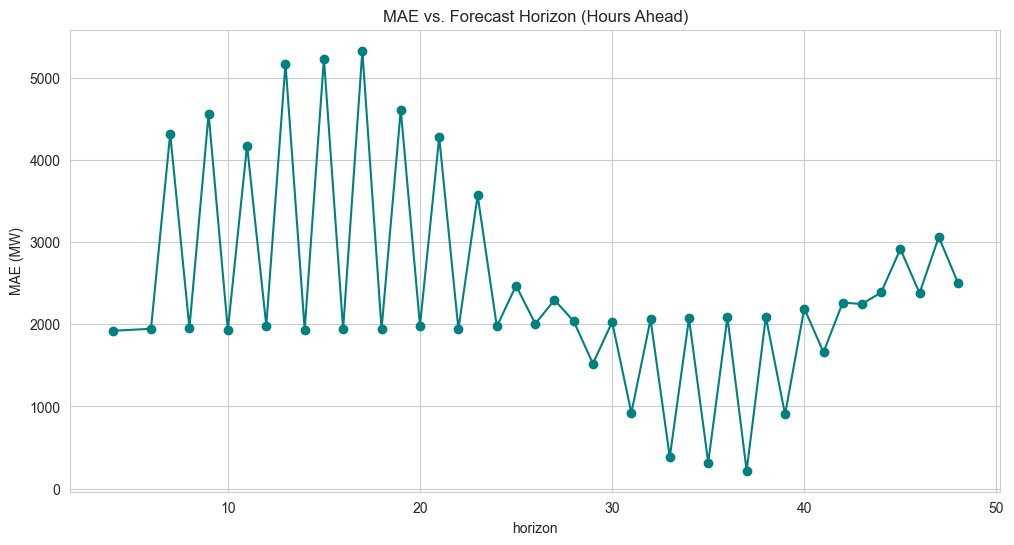

C:\Users\aarin\AppData\Local\Temp\ipykernel_30372\3883103226.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='hour', y='abs_error', estimator=np.mean, palette='viridis')


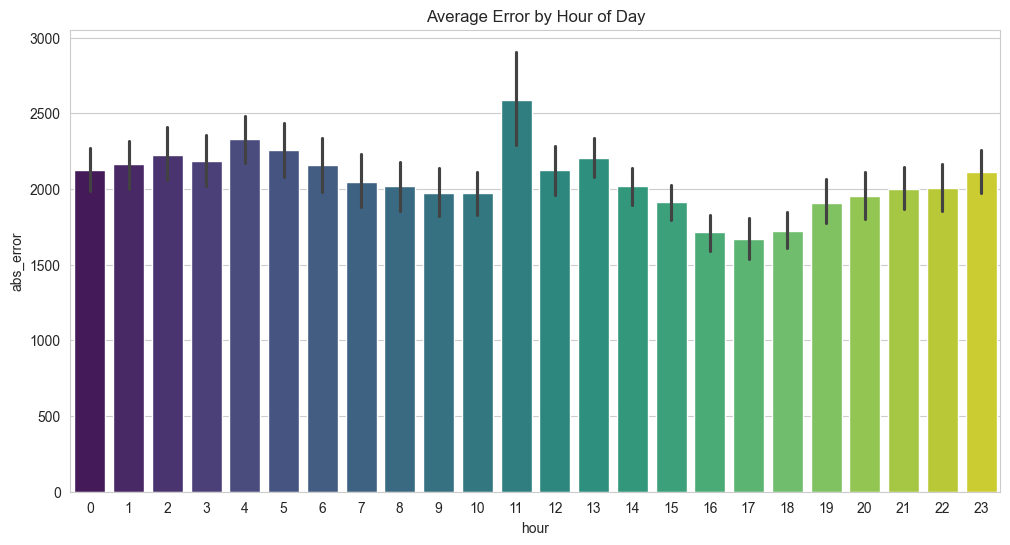

In [13]:
print(f"--- Forecast Error Metrics ---")
print(f"Mean Absolute Error: {df['abs_error'].mean():.2f} MW")
print(f"Median Absolute Error: {df['abs_error'].median():.2f} MW")
print(f"P99 Absolute Error: {df['abs_error'].quantile(0.99):.2f} MW")

# Visualizing Error vs Forecast Horizon
plt.figure()
df.groupby(df['horizon'].round())['abs_error'].mean().plot(marker='o', color='teal')
plt.title('MAE vs. Forecast Horizon (Hours Ahead)')
plt.ylabel('MAE (MW)')
plt.show()

# Visualizing Error by Time of Day
df['hour'] = df['startTime'].dt.hour
plt.figure()
sns.barplot(data=df, x='hour', y='abs_error', estimator=np.mean, palette='viridis')
plt.title('Average Error by Hour of Day')
plt.show()

## 3. Recommended Reliable Capacity
**The Recommendation:** I recommend a reliable capacity of **Mean - 1 Standard Deviation**.

**Reasoning (First Principles):**
1. **Statistical Confidence:** This approach provides a "floor" that we expect actual generation to exceed approximately 84% of the time (assuming normal distribution).
2. **Risk Management:** While a 2-sigma (97% confidence) approach would be safer, it would significantly under-utilize green energy and increase costs by requiring more fossil-fuel backups. 
3. **Evidence:** Given the volatility shown in the P99 metrics, a 1-sigma buffer provides a realistic balance between reliability and economic efficiency.

In [14]:
mean_gen = df['generation_act'].mean()
std_gen = df['generation_act'].std()
reliable_mw = max(0, mean_gen - std_gen)

print(f"Recommended Reliable Capacity: {reliable_mw:.2f} MW")

Recommended Reliable Capacity: 6067.19 MW


## 4. Data Export
**Reasoning:** Finally, we save the merged and filtered dataset. This ensures that the results are reproducible and provides a clean data source for the monitoring application.

In [15]:
# Save the merged results
df.to_csv('wind_analysis_output.csv', index=False)
print("Success: Merged analysis file saved as 'wind_analysis_output.csv'.")

Success: Merged analysis file saved as 'wind_analysis_output.csv'.
